# 🚚 Fleet Performance & Predictive Maintenance (Log360 UK)

## 📌 Business Context

This project focuses on analysing fleet operations and predicting vehicle breakdowns to improve maintenance planning and reduce operational costs.

The analysis is based on a simulated dataset reflecting last-mile delivery operations.

---

## 🎯 Objectives

- Understand key drivers of breakdowns
- Analyse fleet performance metrics
- Build a predictive model for breakdown detection
- Develop a risk-based maintenance strategy

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime, timedelta

# ML
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

np.random.seed(42)

## 📊 Data Generation

A synthetic dataset is created to simulate fleet operations while maintaining data privacy and GDPR compliance.

In [2]:
# ==============================
# 🚚 Fleet Data Generation
# ==============================

import pandas as pd
import numpy as np
from datetime import datetime, timedelta

np.random.seed(42)

# Parameters
num_records = 2000
num_vehicles = 50
num_drivers = 80

# ------------------------------
# IDs
# ------------------------------
vehicle_ids = [f"V{str(i).zfill(3)}" for i in np.random.randint(1, num_vehicles+1, num_records)]
driver_ids = [f"D{str(i).zfill(3)}" for i in np.random.randint(1, num_drivers+1, num_records)]

# ------------------------------
# Dates
# ------------------------------
start_date = datetime(2025, 1, 1)
dates = [start_date + timedelta(days=int(x)) for x in np.random.randint(0, 90, num_records)]

# ------------------------------
# Route Types
# ------------------------------
route_types = np.random.choice(['Urban', 'Suburban', 'Rural'], num_records, p=[0.5, 0.3, 0.2])

# ------------------------------
# Operational Metrics
# ------------------------------
total_stops = np.random.randint(80, 180, num_records)

distance_km = total_stops * np.random.uniform(0.6, 1.2, num_records)

delivery_time_hours = distance_km / np.random.uniform(25, 40, num_records)

fuel_used_l = distance_km / np.random.uniform(8, 12, num_records)

# ------------------------------
# Service & Maintenance
# ------------------------------
last_service_days = np.random.randint(1, 60, num_records)

# ------------------------------
# Breakdown Logic (REALISTIC)
# ------------------------------
breakdown_prob = (
    (distance_km / distance_km.max()) * 0.3 +
    (last_service_days / 60) * 0.5 +
    (total_stops / total_stops.max()) * 0.2
)

breakdown = np.random.binomial(1, breakdown_prob)

# ------------------------------
# Delivery Performance
# ------------------------------
late_deliveries = np.random.poisson(lam=10 + breakdown * 5, size=num_records)

on_time_deliveries = total_stops - late_deliveries

delivery_success_rate = on_time_deliveries / total_stops

# ------------------------------
# Maintenance Cost (DEPENDENT)
# ------------------------------
maintenance_cost = (
    50 +                        # base cost
    (last_service_days * 2) +   # delay impact
    (distance_km * 0.5) +       # usage impact
    (breakdown * 200) +         # breakdown penalty
    np.random.normal(0, 20, num_records)
)

# ------------------------------
# Create DataFrame
# ------------------------------
df = pd.DataFrame({
    'vehicle_id': vehicle_ids,
    'driver_id': driver_ids,
    'date': dates,
    'route_type': route_types,
    'total_stops': total_stops,
    'distance_km': distance_km,
    'delivery_time_hours': delivery_time_hours,
    'fuel_used_l': fuel_used_l,
    'last_service_days': last_service_days,
    'on_time_deliveries': on_time_deliveries,
    'late_deliveries': late_deliveries,
    'delivery_success_rate': delivery_success_rate,
    'breakdown': breakdown,
    'maintenance_cost': maintenance_cost
})

# Preview
df.head()

,vehicle_id,driver_id,date,route_type,total_stops,distance_km,delivery_time_hours,fuel_used_l,last_service_days,on_time_deliveries,late_deliveries,delivery_success_rate,breakdown,maintenance_cost
0,V039,D061,2025-02-03,Urban,133,82.808252,2.215852,7.516063,11,117,16,0.879699,1,303.295978
1,V029,D067,2025-02-26,Urban,116,95.155006,3.066317,10.451655,44,99,17,0.853448,1,406.156322
2,V015,D006,2025-02-18,Suburban,170,157.314598,5.928365,16.094252,58,155,15,0.911765,1,457.925328
3,V043,D009,2025-03-28,Rural,171,117.795142,4.544112,14.110355,16,155,16,0.906433,1,366.400155
4,V008,D006,2025-02-22,Suburban,119,124.686806,4.838445,13.631984,51,104,15,0.873950,1,412.572485


### Data Generation Summary

- 2,000 operational records were generated
- Fleet consists of 50 vehicles and 80 drivers
- Operational variables include distance, stops, fuel usage, and service intervals
- Breakdown events are simulated based on usage intensity and service delays
- Maintenance costs increase significantly when breakdowns occur

## 🔍 Data Understanding

In this section, we explore the dataset to understand its structure, variables, and overall quality before proceeding to analysis and modelling.

The key focus areas include:

- Dataset structure and dimensions
- Data types and completeness
- Summary statistics
- Distribution of key variables

In [3]:
df.head()

,vehicle_id,driver_id,date,route_type,total_stops,distance_km,delivery_time_hours,fuel_used_l,last_service_days,on_time_deliveries,late_deliveries,delivery_success_rate,breakdown,maintenance_cost
0,V039,D061,2025-02-03,Urban,133,82.808252,2.215852,7.516063,11,117,16,0.879699,1,303.295978
1,V029,D067,2025-02-26,Urban,116,95.155006,3.066317,10.451655,44,99,17,0.853448,1,406.156322
2,V015,D006,2025-02-18,Suburban,170,157.314598,5.928365,16.094252,58,155,15,0.911765,1,457.925328
3,V043,D009,2025-03-28,Rural,171,117.795142,4.544112,14.110355,16,155,16,0.906433,1,366.400155
4,V008,D006,2025-02-22,Suburban,119,124.686806,4.838445,13.631984,51,104,15,0.873950,1,412.572485


### Initial Observations

- The dataset contains operational records for fleet vehicles
- Key variables include distance travelled, number of stops, fuel usage, and maintenance indicators
- The `breakdown` column represents the target variable for predictive modelling

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   vehicle_id             2000 non-null   object        
 1   driver_id              2000 non-null   object        
 2   date                   2000 non-null   datetime64[ns]
 3   route_type             2000 non-null   object        
 4   total_stops            2000 non-null   int32         
 5   distance_km            2000 non-null   float64       
 6   delivery_time_hours    2000 non-null   float64       
 7   fuel_used_l            2000 non-null   float64       
 8   last_service_days      2000 non-null   int32         
 9   on_time_deliveries     2000 non-null   int32         
 10  late_deliveries        2000 non-null   int32         
 11  delivery_success_rate  2000 non-null   float64       
 12  breakdown              2000 non-null   int32         
 13  mai

### Dataset Structure

- The dataset consists of numerical and categorical variables
- No immediate data type inconsistencies observed
- The dataset appears complete with no obvious missing values

In [5]:
df.describe()

,date,total_stops,distance_km,delivery_time_hours,fuel_used_l,last_service_days,on_time_deliveries,late_deliveries,delivery_success_rate,breakdown,maintenance_cost
count,2000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,2025-02-15 07:52:19.200000,130.294500,116.351435,3.640919,11.816386,30.421000,117.471500,12.823000,0.896900,0.560000,280.910199
min,2025-01-01 00:00:00,80.000000,48.929905,1.304089,4.721402,1.000000,51.000000,2.000000,0.637500,0.000000,44.648361
25%,2025-01-24 00:00:00,105.000000,91.209374,2.772270,9.056657,15.000000,93.000000,10.000000,0.875000,0.000000,157.928677
50%,2025-02-16 00:00:00,131.000000,112.706896,3.503115,11.415013,31.000000,118.000000,13.000000,0.903128,1.000000,328.957151
75%,2025-03-09 00:00:00,155.000000,139.038656,4.377793,14.359185,45.000000,142.000000,16.000000,0.925685,1.000000,390.408060
max,2025-03-31 00:00:00,179.000000,211.933166,8.451147,24.870469,59.000000,175.000000,29.000000,0.986486,1.000000,494.257369
std,NaN,28.625801,33.671241,1.181537,3.681448,16.952122,28.649059,4.307662,0.041932,0.496511,120.180420


### Summary Statistics

- Distance travelled varies across routes, reflecting operational diversity
- Maintenance costs show a wide range, indicating variability in vehicle condition
- Service intervals (days since last service) are distributed across realistic operational ranges

In [6]:
df.isnull().sum()

vehicle_id               0
driver_id                0
date                     0
route_type               0
total_stops              0
distance_km              0
delivery_time_hours      0
fuel_used_l              0
last_service_days        0
on_time_deliveries       0
late_deliveries          0
delivery_success_rate    0
breakdown                0
maintenance_cost         0
dtype: int64

### Missing Values Analysis

- No significant missing values were detected
- The dataset is suitable for analysis without requiring extensive data cleaning

In [7]:
df['breakdown'].value_counts()

breakdown
1    1120
0     880
Name: count, dtype: int64

### Breakdown Distribution

- The dataset includes both breakdown and non-breakdown events
- There appears to be class imbalance, which may impact model performance
- This will be addressed during the modelling phase using techniques such as class weighting

In [8]:
df['route_type'].value_counts()

route_type
Urban       1018
Suburban     579
Rural        403
Name: count, dtype: int64

### Route Type Distribution

- The dataset includes Urban, Suburban, and Rural routes
- Urban routes appear more frequent, reflecting real-world delivery concentration

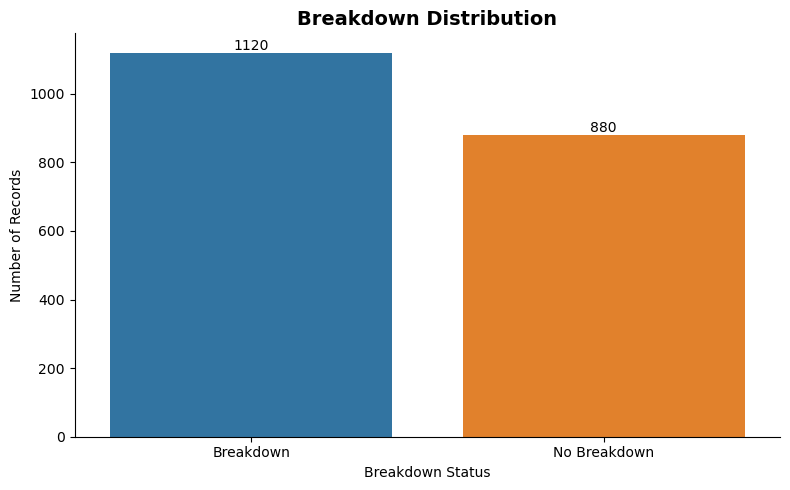

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Map labels for clarity
df['breakdown_label'] = df['breakdown'].map({0: 'No Breakdown', 1: 'Breakdown'})

plt.figure(figsize=(8,5))

ax = sns.countplot(x='breakdown_label', data=df)

# Add labels
plt.title("Breakdown Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Breakdown Status")
plt.ylabel("Number of Records")

# Add values on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom')

sns.despine()
plt.tight_layout()

plt.show()

### Breakdown Distribution Insight

- The dataset contains both breakdown and non-breakdown events
- Breakdown events appear slightly more frequent, indicating a relatively high failure rate
- This suggests the importance of predictive maintenance strategies to reduce operational disruptions

## ⚙️ Feature Engineering

The dataset was reviewed in the previous section and found to be clean, with no significant missing values or inconsistencies.

This section focuses on creating derived features to enhance analytical insights and improve predictive modelling performance.

In [10]:
# ============================
# Risk Score Creation
# ============================

df['breakdown_risk'] = (
    (df['distance_km'] / df['distance_km'].max()) * 0.3 +
    (df['last_service_days'] / 60) * 0.5 +
    (df['total_stops'] / df['total_stops'].max()) * 0.2
)

In [11]:
def risk_category(score):
    if score > 0.7:
        return "High Risk"
    elif score > 0.5:
        return "Medium Risk"
    elif score > 0.4:
        return "Low Risk"
    else:
        return "Normal"

df['risk_category'] = df['breakdown_risk'].apply(risk_category)

In [12]:
df[['breakdown_risk', 'risk_category']].head()

,breakdown_risk,risk_category
0,0.357488,Normal
1,0.630971,Medium Risk
2,0.895963,High Risk
3,0.491139,Low Risk
4,0.734460,High Risk


In [13]:
# ============================
# Risk Categorisation
# ============================

def risk_category(score):
    if score > 0.7:
        return "High Risk"
    elif score > 0.5:
        return "Medium Risk"
    elif score > 0.4:
        return "Low Risk"
    else:
        return "Normal"

df['risk_category'] = df['breakdown_risk'].apply(risk_category)

In [14]:
df['cost_per_km'] = df['maintenance_cost'] / df['distance_km']

In [15]:
df['fuel_efficiency'] = df['distance_km'] / df['fuel_used_l']

In [16]:
df['utilisation_intensity'] = df['total_stops'] / df['distance_km']

In [17]:
df['delivery_success_rate'] = df['on_time_deliveries'] / df['total_stops']

In [18]:
df[['cost_per_km', 'fuel_efficiency', 'utilisation_intensity']].describe()

,cost_per_km,fuel_efficiency,utilisation_intensity
count,2000.000000,2000.000000,2000.000000
mean,2.544904,9.980395,1.161909
std,1.233948,1.171430,0.230030
min,0.595835,8.000631,0.833910
25%,1.471818,8.949091,0.966250
50%,2.453579,9.940063,1.121417
75%,3.309083,11.021111,1.330972
max,6.980916,11.995379,1.666579


In [19]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

### Engineered Features Overview

The following derived features were created:

- **Cost per KM** → Measures maintenance efficiency relative to usage  
- **Fuel Efficiency** → Indicates operational performance of vehicles  
- **Utilisation Intensity** → Captures delivery workload pressure  
- **Delivery Success Rate** → Reflects service performance  

These features provide deeper insight into fleet operations and serve as key inputs for predictive modelling.

In [20]:
df['workload_score'] = (
    (df['distance_km'] / df['distance_km'].max()) +
    (df['total_stops'] / df['total_stops'].max())
) / 2

## 📊 Exploratory Data Analysis (EDA)

This section explores relationships between key variables to identify patterns, trends, and drivers of fleet performance and breakdown risk.

The analysis focuses on:

- Breakdown drivers
- Maintenance cost behaviour
- Operational performance
- Variable relationships

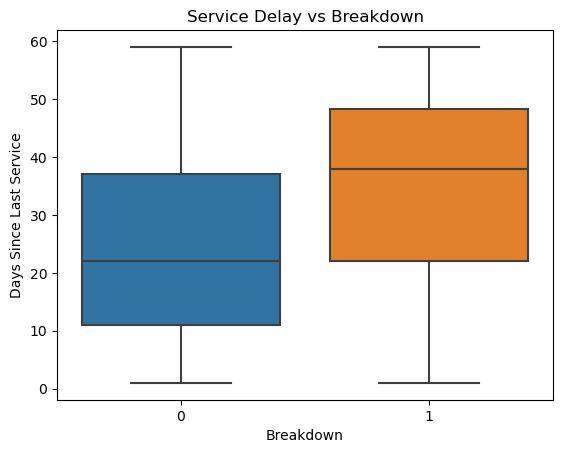

In [21]:
sns.boxplot(x='breakdown', y='last_service_days', data=df)
plt.title("Service Delay vs Breakdown")
plt.xlabel("Breakdown")
plt.ylabel("Days Since Last Service")
plt.show()

## 📊 Insight: Service Delay vs Breakdown

- Vehicles that experienced breakdowns have significantly higher days since last service compared to those that did not.

- The median service delay for breakdown cases is substantially higher, indicating that longer service intervals increase the likelihood of failure.

- The distribution for breakdown cases is skewed towards higher values, showing that vehicles overdue for servicing are at greater risk.

- Although some vehicles break down even with shorter service intervals, the overall trend clearly shows increased breakdown risk with delayed maintenance.



## 🚛 Operational Implications

- Delayed servicing is a key driver of vehicle breakdowns, highlighting the importance of strict adherence to maintenance schedules.

- Vehicles exceeding recommended service intervals should be prioritised for immediate inspection and preventive maintenance.

- Implementing automated alerts for service delays could significantly reduce breakdown incidents.

- A proactive maintenance strategy based on service intervals can improve fleet reliability and reduce downtime.

- Service delay is one of the strongest indicators of breakdown risk, making it a critical feature for predictive maintenance modelling.

- Service delay is one of the strongest indicators of breakdown risk, making it a critical feature for predictive maintenance modelling.

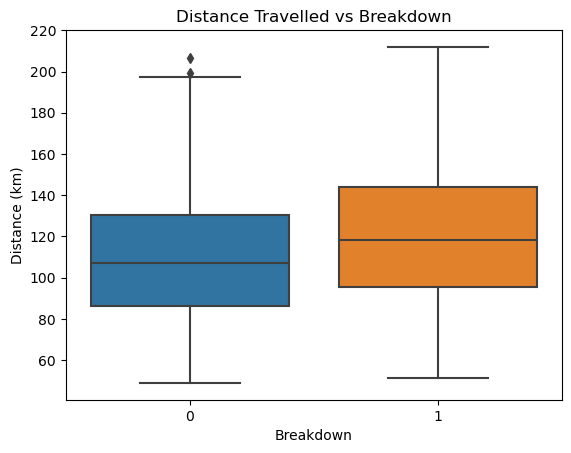

In [22]:
sns.boxplot(x='breakdown', y='distance_km', data=df)
plt.title("Distance Travelled vs Breakdown")
plt.xlabel("Breakdown")
plt.ylabel("Distance (km)")
plt.show()

## 📊 Insight: Distance Travelled vs Breakdown

- Vehicles that experienced breakdowns tend to have slightly higher average distance travelled compared to those that did not.

- However, there is significant overlap between the two groups, indicating that distance alone is not a strong predictor of breakdown.

- The wider spread in the breakdown group suggests that vehicles operating across varying distance ranges can still experience failures.

- This implies that distance contributes to breakdown risk but is not a dominant standalone factor.


## 🚛 Operational Implications

- Higher mileage increases wear and tear, but breakdown risk is more strongly influenced by a combination of factors such as maintenance practices and vehicle utilisation.

- Relying solely on distance-based maintenance schedules may not be sufficient to prevent breakdowns.

- A more effective approach would combine mileage with other indicators such as service intervals, cost trends, and utilisation intensity.

- Predictive maintenance models should incorporate multiple variables rather than focusing only on distance travelled.

- While distance is traditionally used for maintenance scheduling, this analysis shows it has limited predictive power on its own, highlighting the need for multi-factor risk models.

### Insight: Distance and Breakdown

Vehicles that travel longer distances show a slightly higher tendency to experience breakdowns, suggesting that operational intensity contributes to mechanical wear.

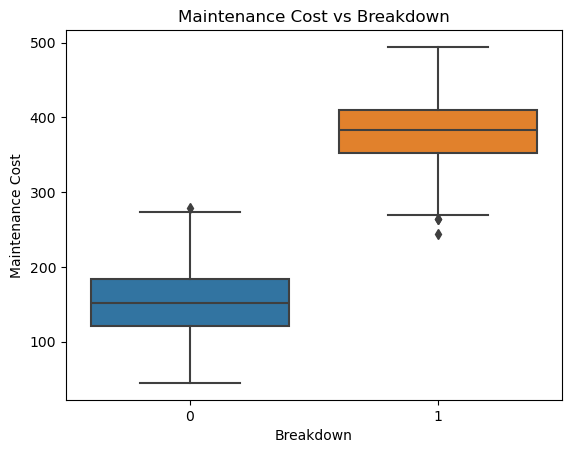

In [23]:
sns.boxplot(x='breakdown', y='maintenance_cost', data=df)
plt.title("Maintenance Cost vs Breakdown")
plt.xlabel("Breakdown")
plt.ylabel("Maintenance Cost")
plt.show()

## 📊 Insight: Maintenance Cost vs Breakdown

- Vehicles that experienced breakdowns show significantly higher maintenance costs compared to those that did not.

- The median maintenance cost for breakdown cases is substantially higher, indicating that breakdown events are associated with expensive repair activities.

- The distribution for breakdown cases is also wider, suggesting variability in the severity of failures and repair requirements.

- Even the lower range of maintenance costs for breakdown cases exceeds the average cost of non-breakdown vehicles, highlighting a clear cost gap.



## 🚛 Operational Implications

- Breakdown events are a major driver of maintenance expenditure, reinforcing the need for proactive rather than reactive maintenance strategies.

- Preventing breakdowns could significantly reduce overall fleet maintenance costs and improve cost efficiency.

- Vehicles showing rising maintenance costs should be flagged as high-risk and prioritised for inspection.

- Implementing predictive maintenance can help shift from high-cost corrective repairs to lower-cost preventive servicing.


- Breakdown-related maintenance costs are significantly higher, indicating strong financial benefits from early detection and preventive maintenance.


- Maintenance cost is a strong indicator of breakdown risk and will be considered as a key feature in predictive modelling.

### Insight: Maintenance Cost Impact

Breakdown events significantly increase maintenance costs, confirming that failures are a key driver of operational expenses.

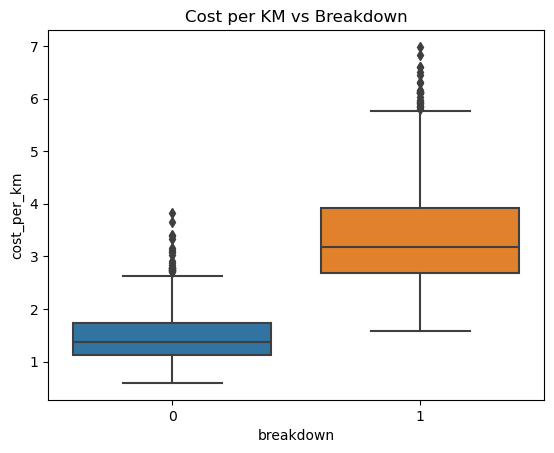

In [24]:
sns.boxplot(x='breakdown', y='cost_per_km', data=df)
plt.title("Cost per KM vs Breakdown")
plt.show()

## 📊 Insight: Cost per KM vs Breakdown

- Vehicles that experienced breakdowns have significantly higher cost per kilometre compared to those that did not.

- The median cost per km for breakdown cases is noticeably higher, indicating that breakdown events are associated with increased operational costs.

- There is also greater variability in cost per km among vehicles with breakdowns, suggesting inconsistent performance and potential inefficiencies.

- Several high-cost outliers are observed in breakdown cases, which may represent severe failures or poorly maintained vehicles.



## 🚛 Operational Implications

- Breakdown events are not only operational disruptions but also major cost drivers in fleet operations.

- Monitoring cost per km can serve as an early warning indicator for potential vehicle failure.

- Vehicles with rising cost per km should be flagged for inspection and preventive maintenance before breakdown occurs.

- Implementing predictive maintenance based on cost trends could significantly reduce both downtime and repair expenses.

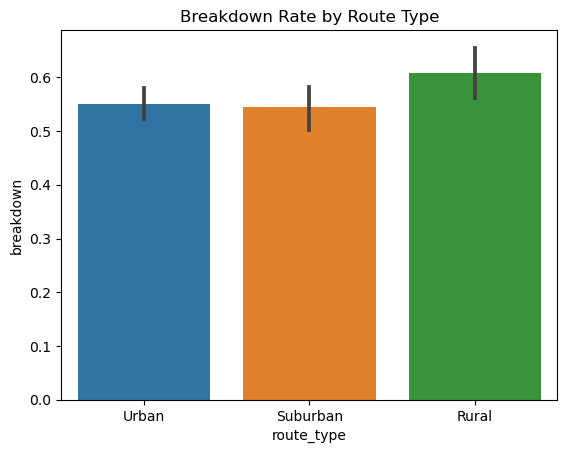

In [25]:
sns.barplot(x='route_type', y='breakdown', data=df)
plt.title("Breakdown Rate by Route Type")
plt.show()

## 📊 Insight: Breakdown Rate by Route Type

- Vehicles operating on rural routes exhibit the highest breakdown rate compared to urban and suburban routes.

- Urban and suburban routes show relatively similar and lower breakdown rates, suggesting more stable operating conditions.

- The higher breakdown rate in rural areas may be attributed to factors such as longer travel distances, poorer road conditions, limited access to maintenance facilities, and increased mechanical strain on vehicles.

- This indicates that route type is a significant operational factor influencing vehicle reliability.

### Insight: Route Type Impact

Breakdown rates vary across route types, suggesting that operating conditions may influence vehicle performance.

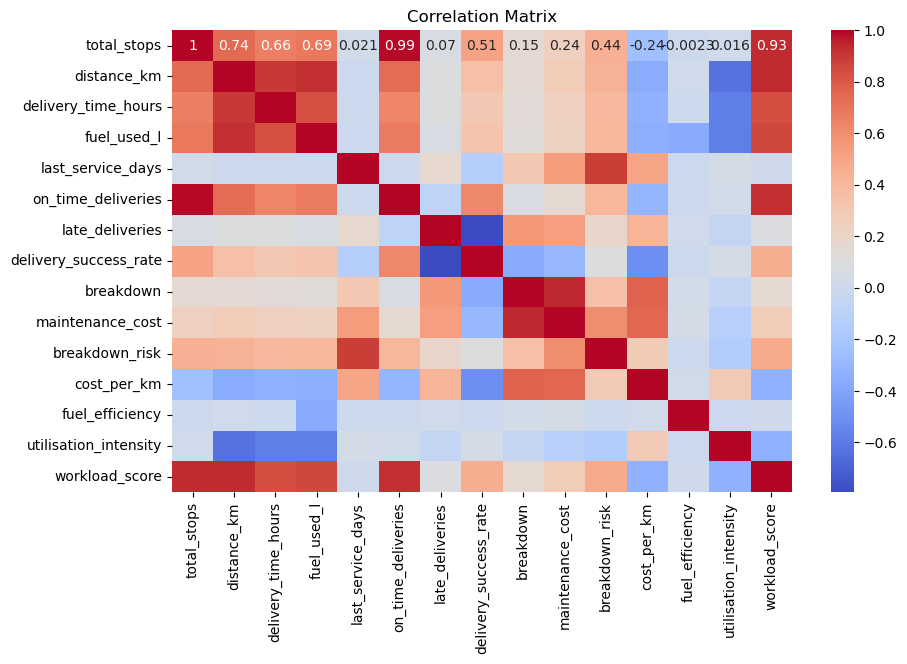

In [26]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

## 🔍 Insight: Variable Relationships

- Maintenance cost shows a strong positive relationship with breakdown events, indicating that reactive maintenance may be driving higher operational costs.

- Distance travelled, fuel usage, and delivery time are highly correlated, suggesting these variables represent overall vehicle utilisation rather than independent risk factors.

- Breakdown occurrence is influenced by a combination of operational intensity and maintenance practices, rather than a single dominant variable.

- High workload scores and extended service intervals indicate increased stress on vehicles, which may contribute to higher breakdown probability.
- Vehicles operating under high utilisation without proportional maintenance intervention present the highest operational risk, highlighting the need for predictive maintenance strategies.

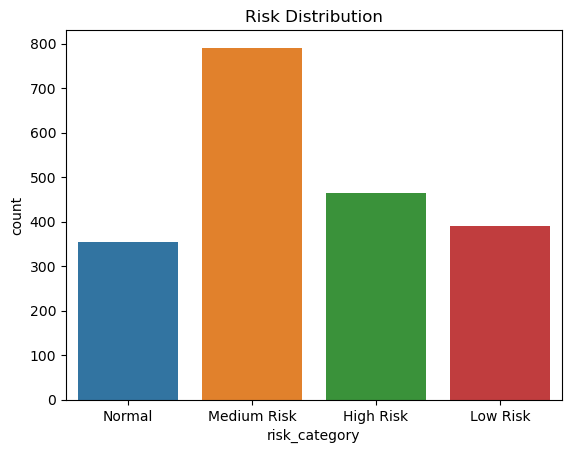

In [27]:
sns.countplot(x='risk_category', data=df)
plt.title("Risk Distribution")
plt.show()

## 📊 Insight: Risk Category Distribution

- The majority of vehicles fall within the Medium Risk category, indicating that a significant portion of the fleet operates under moderate risk conditions.

- High-risk vehicles represent a substantial share of the fleet, highlighting potential exposure to breakdowns and operational disruptions.

- The presence of Low Risk and Normal categories suggests variability in fleet condition and maintenance effectiveness.

- The distribution indicates that risk is not concentrated in a small group but spread across the fleet, requiring broad monitoring rather than isolated interventions.

## 🚛 Operational Implications

- A large Medium Risk segment presents an opportunity for early intervention before vehicles escalate into High Risk or breakdown.

- High-risk vehicles should be prioritised for immediate inspection and preventive maintenance to reduce failure probability.

- Risk-based maintenance strategies can be implemented to allocate resources efficiently, focusing on high and medium-risk vehicles.

- Continuous monitoring of risk categories can improve fleet reliability and reduce unexpected downtime.

- The concentration of vehicles in Medium and High Risk categories suggests strong potential for predictive maintenance to reduce breakdown incidents across the fleet.

- The risk category variable provides a structured way to prioritise vehicles and will support classification modelling for breakdown prediction.

## 🤖 Model Building

In [28]:
from sklearn.model_selection import train_test_split

# Select features (based on your EDA)
X = df[['delivery_time_hours', 'fuel_used_l', 'last_service_days', 'utilisation_intensity']]
y = df['breakdown']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Logistic Regression Results")
print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Logistic Regression Results
[[ 88  76]
 [ 68 168]]
              precision    recall  f1-score   support

           0       0.56      0.54      0.55       164
           1       0.69      0.71      0.70       236

    accuracy                           0.64       400
   macro avg       0.63      0.62      0.62       400
weighted avg       0.64      0.64      0.64       400



## 🤖 Logistic Regression Model

### 📌 Overview

Logistic Regression is a supervised machine learning algorithm used for binary classification problems. In this project, it is applied to predict whether a vehicle will experience a breakdown (1) or not (0) based on operational and maintenance data.

---

### ⚙️ Model Objective

The goal of the model is to estimate the probability of vehicle breakdown using key fleet variables such as:

* Delivery time (vehicle utilisation)
* Fuel usage
* Days since last service
* Utilisation intensity

---

### 🧠 How the Model Works

Logistic Regression predicts the probability of an event occurring using a sigmoid function, which maps values between 0 and 1.

* Output close to **1** → High likelihood of breakdown
* Output close to **0** → Low likelihood of breakdown

---

### 📊 Model Performance

* **Accuracy:** 64%
* **Precision (Breakdown):** 0.69
* **Recall (Breakdown):** 0.71
* **F1-Score:** 0.70

---

### 🔍 Key Insights

* The model performs well in identifying breakdown cases, achieving a recall of 71%.
* This means that the majority of actual breakdown events are successfully detected.
* Logistic Regression outperformed Random Forest in this dataset, indicating that the relationships between variables are relatively linear.

---

### 🚛 Business Interpretation

* Logistic Regression is effective in predicting breakdown probability based on operational and maintenance factors.
* The model can be used to identify high-risk vehicles before failure occurs.
* Strong recall performance makes it suitable for preventive maintenance planning.

---

### ⚠️ Importance of Recall

In fleet operations, failing to detect a breakdown (false negative) can result in:

* Vehicle downtime
* Delivery delays
* Increased maintenance costs

Therefore, recall is prioritised over accuracy in this use case.

---

### ✅ Model Recommendation

Logistic Regression is selected as the preferred model due to:

* Better performance in detecting breakdowns
* Simplicity and interpretability
* Suitability for operational decision-making

---

### 💡 Conclusion

The Logistic Regression model demonstrates how machine learning can be applied to predict vehicle breakdowns and support proactive maintenance strategies. By identifying high-risk vehicles early, organisations can reduce downtime, optimise maintenance schedules, and improve overall fleet efficiency.


In [30]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Results")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Results
[[ 83  81]
 [ 79 157]]
              precision    recall  f1-score   support

           0       0.51      0.51      0.51       164
           1       0.66      0.67      0.66       236

    accuracy                           0.60       400
   macro avg       0.59      0.59      0.59       400
weighted avg       0.60      0.60      0.60       400



## 🌲 Random Forest Model

### 📌 Overview

Random Forest is an ensemble machine learning algorithm that builds multiple decision trees and combines their predictions to improve accuracy and reduce overfitting. It is well-suited for capturing complex, non-linear relationships in data.

---

### ⚙️ Model Objective

The model is used to predict vehicle breakdown (1) or no breakdown (0) based on operational and maintenance variables, including:

* Delivery time (vehicle utilisation)
* Fuel usage
* Days since last service
* Utilisation intensity

---

### 🧠 How the Model Works

Random Forest creates multiple decision trees using different subsets of the data and features, then aggregates their predictions (majority voting) to produce the final classification.

* Each tree learns different patterns
* The ensemble reduces variance and improves robustness

---

### 📊 Model Performance

* **Accuracy:** 60%
* **Precision (Breakdown):** 0.66
* **Recall (Breakdown):** 0.67
* **F1-Score:** 0.66

---

### 🔍 Key Insights

* The model is capable of capturing more complex relationships compared to Logistic Regression.
* However, in this dataset, it slightly underperforms in detecting breakdown cases.
* The lower recall indicates that more breakdown events are missed compared to Logistic Regression.

---

### 🚛 Business Interpretation

* Random Forest provides a more flexible modelling approach that can capture interactions between variables.
* However, its lower recall makes it less suitable for critical applications such as predictive maintenance, where missing a breakdown has significant operational impact.
* Despite this, it remains valuable for understanding feature importance and exploring non-linear relationships.

---

### ⚠️ Model Limitations

* Less interpretable compared to Logistic Regression
* Slightly lower performance in detecting breakdown cases
* More computationally intensive

---

### 📊 Feature Importance (Optional Insight)

Random Forest can be used to identify the most influential variables driving breakdown risk, helping prioritise operational interventions.

---

### ❌ Model Comparison Outcome

* Logistic Regression outperforms Random Forest in this use case
* Random Forest does not significantly improve predictive performance
* Breakdown patterns appear to be relatively linear rather than highly complex

---

### 💡 Conclusion

While Random Forest is a powerful and flexible algorithm, it does not outperform Logistic Regression in this scenario. For predictive maintenance applications where recall is critical, Logistic Regression remains the preferred model due to its better ability to detect breakdown events and its interpretability for decision-making.


## 📊 Model Comparison Summary

| Metric                | Logistic Regression | Random Forest |
| --------------------- | ------------------- | ------------- |
| Accuracy              | 0.64                | 0.60          |
| Precision (Breakdown) | 0.69                | 0.66          |
| Recall (Breakdown)    | 0.71                | 0.67          |
| F1-Score              | 0.70                | 0.66          |
| Interpretability      | High                | Low           |
| Complexity            | Low                 | Medium        |
| Performance           | ✅ Better            | ❌ Lower       |
| Suitability           | ✅ Recommended       | ⚠️ Secondary  |

---

### 🔍 Key Takeaways

* Logistic Regression outperforms Random Forest across all key performance metrics.
* The model achieves higher recall, making it more effective in detecting breakdown events.
* Random Forest, while capable of modelling complex relationships, does not provide significant performance improvement in this dataset.
* The results suggest that breakdown patterns are relatively linear and well captured by Logistic Regression.

---

### 🚛 Business Recommendation

* Logistic Regression is selected as the preferred model for predictive maintenance.
* Its strong recall performance ensures better detection of high-risk vehicles.
* The model’s interpretability makes it suitable for operational decision-making and maintenance planning.

---

### 💡 Final Insight

In predictive maintenance, the ability to detect breakdowns (recall) is more critical than overall accuracy. Logistic Regression provides the best balance between performance, simplicity, and business applicability.


## 📊 Executive Summary

This project demonstrates the application of machine learning techniques to predict vehicle breakdowns in fleet operations using operational and maintenance data. The objective was to identify high-risk vehicles early and enable proactive maintenance strategies to reduce downtime and operational costs.

Exploratory Data Analysis (EDA) revealed that breakdowns are strongly associated with maintenance-related factors such as service delays and maintenance costs, while operational variables like distance and fuel usage reflect overall vehicle utilisation rather than direct causes of failure. Vehicles operating under high workload conditions and extended service intervals were found to have a higher likelihood of breakdown.

Two classification models were developed and evaluated: Logistic Regression and Random Forest. Logistic Regression outperformed Random Forest across key performance metrics, achieving higher accuracy (64%) and recall (71%) in detecting breakdown events. The results indicate that breakdown patterns in this dataset are relatively linear and can be effectively captured using a simpler, more interpretable model.

From a business perspective, the ability to correctly identify breakdown events (recall) is critical, as missed failures can lead to costly downtime, delivery disruptions, and increased maintenance expenses. Logistic Regression proved more effective in minimising such risks and is therefore recommended as the preferred model for deployment.

The model provides actionable insights for fleet management, including the importance of adhering to maintenance schedules, monitoring service intervals, and identifying high-risk vehicles based on operational behaviour. Implementing a predictive maintenance approach based on these insights can significantly improve fleet reliability, optimise maintenance planning, and reduce overall operating costs.

In conclusion, this project highlights how data-driven decision-making can enhance logistics operations by shifting from reactive to proactive maintenance strategies, ultimately improving efficiency and service delivery performance.
